Importy

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import glob
import itertools
import copy
import os

WSPÓLNE FUNKCJE I KLASY SIECI

In [2]:
class SubNetwork(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super(SubNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x): return self.net(x)

def train_greybox_model(model, dataloader, epochs=2000, patience=80, min_delta=1e-6):
    optimizer = optim.Adam(model.parameters(), lr=5e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.95)
    criterion = nn.L1Loss() 
    
    # --- Zmienne dla Early Stopping ---
    best_loss = float('inf') # Ustawiamy początkowy "najlepszy" błąd na nieskończoność
    patience_counter = 0     # Licznik epok bez poprawy
    best_model_weights = copy.deepcopy(model.state_dict()) # Tu będziemy trzymać kopię najlepszych wag
    
    model.train()
    print(f"Rozpoczynam trening (Maksymalnie {epochs} epok, Cierpliwość: {patience})...")
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # Przejście przez wszystkie paczki danych
        for u_seq, y_true_seq in dataloader:
            x_init = torch.zeros(u_seq.size(0), model.num_states)
            optimizer.zero_grad()
            y_pred_seq = model(u_seq, x_init)
            loss = criterion(y_pred_seq.view_as(y_true_seq), y_true_seq)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        scheduler.step()
        avg_loss = epoch_loss / len(dataloader)
        
        # Wypisywanie postępu
        if (epoch + 1) % 10 == 0:
            print(f"Epoka {epoch+1}/{epochs} | Strata MSE: {avg_loss:.6f}")
            
        # --- LOGIKA EARLY STOPPING ---
        # Sprawdzamy, czy obecna strata jest zauważalnie lepsza od najlepszej dotychczasowej
        if best_loss - avg_loss > min_delta:
            best_loss = avg_loss               # Zapisujemy nowy rekord
            patience_counter = 0               # Zerujemy licznik cierpliwości
            best_model_weights = copy.deepcopy(model.state_dict()) # Kopiujemy i zapisujemy te najlepsze wagi!
        else:
            patience_counter += 1              # Brak poprawy, zwiększamy licznik
            
        # Jeśli straciliśmy cierpliwość (licznik przekroczył limit)
        if patience_counter >= patience:
            print(f"\n[!] EARLY STOPPING: Przerwano trening w epoce {epoch+1}!")
            print(f"Brak poprawy o minimum {min_delta} od {patience} epok.")
            break # Wychodzimy z głównej pętli treningowej
            
    # Po zakończeniu pętli (niezależnie czy doszła do 2000, czy ucięło ją wcześnie)
    # wgrywamy z powrotem NAJLEPSZE wagi, żeby nie zwracać modelu z ostatniej, gorszej epoki.
    model.load_state_dict(best_model_weights)
    print(f"Trening zakończony. Załadowano najlepsze wagi ze stratą MSE: {best_loss:.6f}\n")
    
    return model

def create_sequences(inputs, targets, seq_len=600):
    xs, ys = [], []
    for i in range(0, len(inputs) - seq_len + 1, seq_len):
        xs.append(inputs[i : i + seq_len])
        ys.append(targets[i : i + seq_len])
    return np.array(xs), np.array(ys)


# ULEPSZONA FUNKCJA WALIDACJI Z FILTREM REZIDUUM I "STREFĄ CISZY" (Burn-in)
# ==========================================
def validate_and_plot(model, scaler_u, scaler_y, input_cols, target_cols, file_path, title_prefix, alpha=0.05, threshold=None, burn_in=0):
    # Wczytanie i przygotowanie danych
    df_test = pd.read_csv(file_path)
    X_test_tensor = torch.tensor(scaler_u.transform(df_test[input_cols].values), dtype=torch.float32).unsqueeze(0)
    Y_test_tensor = torch.tensor(scaler_y.transform(df_test[target_cols].values), dtype=torch.float32).unsqueeze(0)
    
    # Przewidywanie modelu
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor, torch.zeros(1, model.num_states))
        
    y_pred_real = scaler_y.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
    y_true_real = scaler_y.inverse_transform(Y_test_tensor[0].cpu().numpy().reshape(-1, 1))
    czas = np.arange(len(y_true_real)) * 0.05
    
    # ---------------------------------------------------------
    # OBLICZANIE I FILTROWANIE REZIDUUM (BŁĘDU BEZWZGLĘDNEGO)
    # ---------------------------------------------------------
    e_raw = np.abs(y_true_real - y_pred_real) # Surowy błąd (z Twojego kodu)
    e_filtered = np.zeros_like(e_raw)         # Pusta tablica na przefiltrowany błąd
    e_filtered[0] = e_raw[0]                  # Stan początkowy
    
    # Pętla filtru EMA (Exponential Moving Average - Filtr dolnoprzepustowy I rzędu)
    for i in range(1, len(e_raw)):
        e_filtered[i] = alpha * e_raw[i] + (1 - alpha) * e_filtered[i-1]
        
    # --- NAPRAWA BŁĘDU STANU POCZĄTKOWEGO (Burn-in period) ---
    # Sztuczne wyzerowanie błędu dla pierwszych N próbek (np. 50 próbek = 2.5 sekundy), 
    # żeby model zdążył się numerycznie "napompować" do wartości fizycznych.
    if burn_in > 0:
        e_raw[:burn_in] = 0.0
        e_filtered[:burn_in] = 0.0
    
    # ---------------------------------------------------------
    # RYSOWANIE WYKRESÓW
    # ---------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Górny wykres: Fizyka
    ax1.plot(czas, y_true_real, label='Prawda (Czujnik)', color='black', alpha=0.7)
    ax1.plot(czas, y_pred_real, label='Symulacja (AI)', color='red', linestyle='--', alpha=0.9)
    ax1.set_title(f'{title_prefix} | Plik: {file_path.split("/")[-1]}', fontsize=12)
    ax1.set_ylabel('Wartość fizyczna (np. Pa)')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Dolny wykres: Diagnostyka
    ax2.plot(czas, e_raw, label='Surowe Reziduum (Szum)', color='gray', alpha=0.4)
    ax2.plot(czas, e_filtered, label=f'Przefiltrowane Reziduum (alpha={alpha})', color='darkred', linewidth=2)
    
    # Jeśli podałeś próg alarmowy, narysuj go
    if threshold is not None:
        ax2.axhline(threshold, color='orange', linestyle='--', linewidth=2, label=f'Próg Detekcji ({threshold})')
        
    ax2.set_title('Sygnał Diagnostyczny (Reziduum)', fontsize=12)
    ax2.set_xlabel('Czas [s]')
    ax2.set_ylabel('Błąd predykcji')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Do liczenia statystyk bierzemy dane dopiero PO fazie rozgrzewki, 
    # żeby ten gigantyczny spadek początkowy nie niszczył wyników MAE!
    print(f"Średni błąd bezwzględny (MAE po rozgrzewce): {np.mean(e_raw[burn_in:]):.4f}")
    print(f"Maksymalny błąd przefiltrowany (po rozgrzewce): {np.max(e_filtered[burn_in:]):.4f}")

MSO_0 - kolektor dolotowy

In [3]:
class GreyBoxSystem_MSO0(nn.Module):
    def __init__(self, T_sample=0.05, num_states = 3):
        super(GreyBoxSystem_MSO0, self).__init__()
        self.T, self.num_states, self.num_inputs = T_sample, 1, 4
        total_feat = self.num_states + self.num_inputs
        self.g_func, self.h_func = SubNetwork(total_feat, 1), SubNetwork(total_feat, 1)

    def forward(self, u_seq, x_init):
        x_t, preds = x_init, []
        for t in range(u_seq.size(1)):
            inputs = torch.cat((x_t, u_seq[:, t, :]), dim=1)
            preds.append(self.h_func(inputs))
            x_t = x_t + self.T * self.g_func(inputs)
        return torch.stack(preds, dim=1)

# Kolumny i ładowanie (podmień ścieżki na swoje folder z /NF.csv)
u_cols_0 = ['injected_fuel_mass', 'throttle_position', 'intercooler_temperature', 'intake_manifold_pressure']
y_cols_0 = ['air_mass_flow']

# Zakładamy, że masz połączony DataFrame "df_train_nf" ze zdrowymi danymi
DATA_DIR = r"C:\Users\anton\OneDrive\Desktop\data"

HEALTHY_FILES = glob.glob(os.path.join(DATA_DIR, "*_NF*.csv"))
FAULTY_FILES_PIM = glob.glob(os.path.join(DATA_DIR, "*_f_pim*.csv"))
FAULTY_FILES_PIC = glob.glob(os.path.join(DATA_DIR, "*_f_pic*.csv"))
FAULTY_FILES_WAF = glob.glob(os.path.join(DATA_DIR, "*_f_waf*.csv"))
FAULTY_FILES_IML = glob.glob(os.path.join(DATA_DIR, "*_f_iml*.csv"))

healthy_dfs = [pd.read_csv(f) for f in HEALTHY_FILES]
faulty_dfs_pim = [pd.read_csv(f) for f in FAULTY_FILES_PIM]
faulty_dfs_pic = [pd.read_csv(f) for f in FAULTY_FILES_PIC]
faulty_dfs_iml = [pd.read_csv(f) for f in FAULTY_FILES_IML]

df_train_nf = pd.concat(healthy_dfs + faulty_dfs_pim + faulty_dfs_pic + faulty_dfs_iml, ignore_index=True)

scaler_u0, scaler_y0 = MinMaxScaler(), MinMaxScaler()
u0_norm = scaler_u0.fit_transform(df_train_nf[u_cols_0].values)
y0_norm = scaler_y0.fit_transform(df_train_nf[y_cols_0].values)

X_seq0, Y_seq0 = create_sequences(u0_norm, y0_norm)
loader0 = DataLoader(TensorDataset(torch.tensor(X_seq0, dtype=torch.float32), torch.tensor(Y_seq0, dtype=torch.float32)), batch_size=16, shuffle=True)

#Trenujemy i zapisujemy! (Odkomentuj, gdy chcesz trenować)
model_0 = GreyBoxSystem_MSO0()
model_0 = train_greybox_model(model_0, loader0, epochs=2000)

torch.save(model_0.state_dict(), 'szara_skrzynka_waf.pth')
joblib.dump(scaler_u0, 'scaler_u_waf.pkl')
joblib.dump(scaler_y0, 'scaler_y_waf.pkl')

print("MSO 0 gotowe i zapisane!")

Rozpoczynam trening (Maksymalnie 2000 epok, Cierpliwość: 80)...
Epoka 10/2000 | Strata MSE: 0.013273
Epoka 20/2000 | Strata MSE: 0.010731
Epoka 30/2000 | Strata MSE: 0.010613
Epoka 40/2000 | Strata MSE: 0.009955
Epoka 50/2000 | Strata MSE: 0.009511
Epoka 60/2000 | Strata MSE: 0.008926
Epoka 70/2000 | Strata MSE: 0.009052
Epoka 80/2000 | Strata MSE: 0.008238
Epoka 90/2000 | Strata MSE: 0.008249
Epoka 100/2000 | Strata MSE: 0.007856
Epoka 110/2000 | Strata MSE: 0.007948
Epoka 120/2000 | Strata MSE: 0.007701
Epoka 130/2000 | Strata MSE: 0.007683
Epoka 140/2000 | Strata MSE: 0.007603
Epoka 150/2000 | Strata MSE: 0.007394
Epoka 160/2000 | Strata MSE: 0.007227
Epoka 170/2000 | Strata MSE: 0.007338
Epoka 180/2000 | Strata MSE: 0.008050
Epoka 190/2000 | Strata MSE: 0.007244
Epoka 200/2000 | Strata MSE: 0.007037
Epoka 210/2000 | Strata MSE: 0.006868
Epoka 220/2000 | Strata MSE: 0.006861
Epoka 230/2000 | Strata MSE: 0.006842
Epoka 240/2000 | Strata MSE: 0.006658
Epoka 250/2000 | Strata MSE: 0.00

Walidacja

Model MSO 0 i skalery zostały pomyślnie wczytane z dysku!


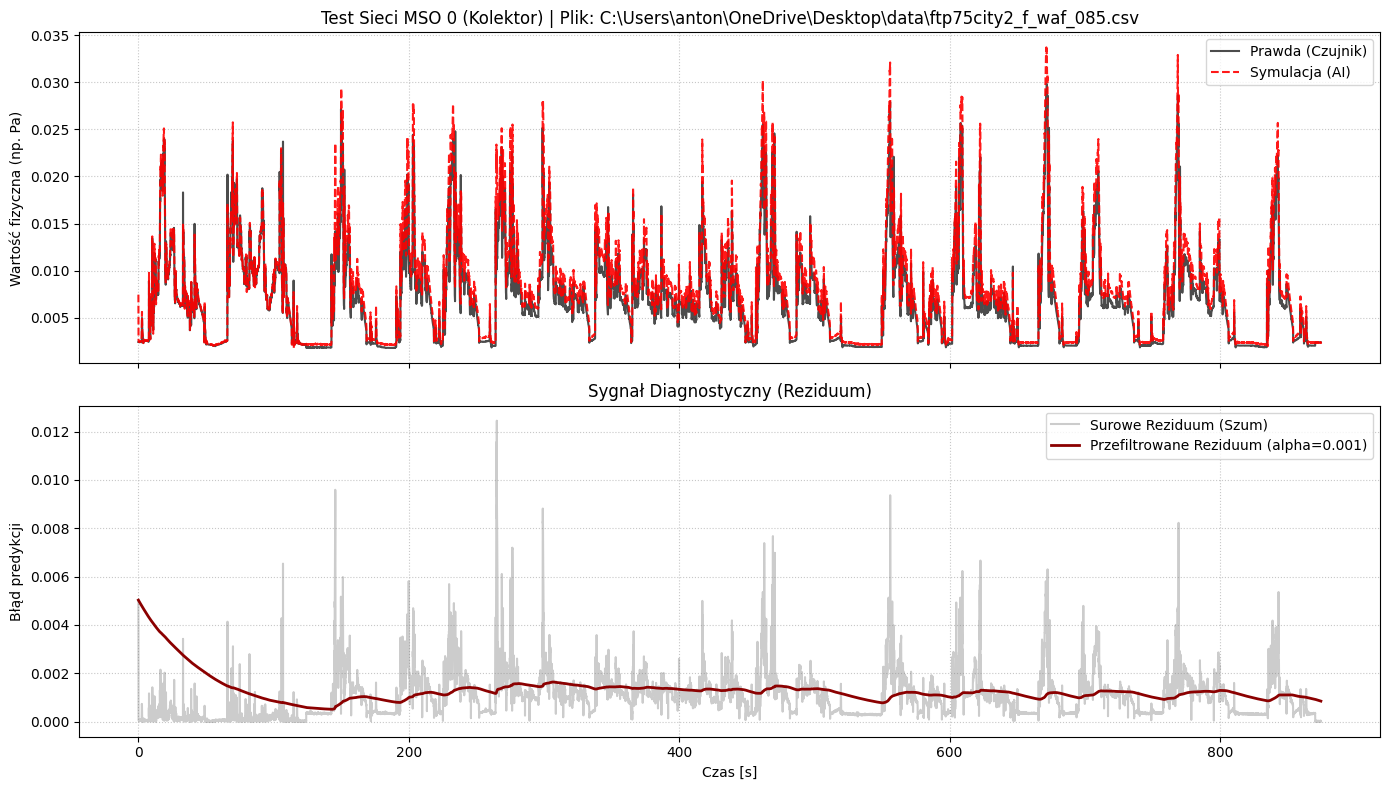

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0011
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0050


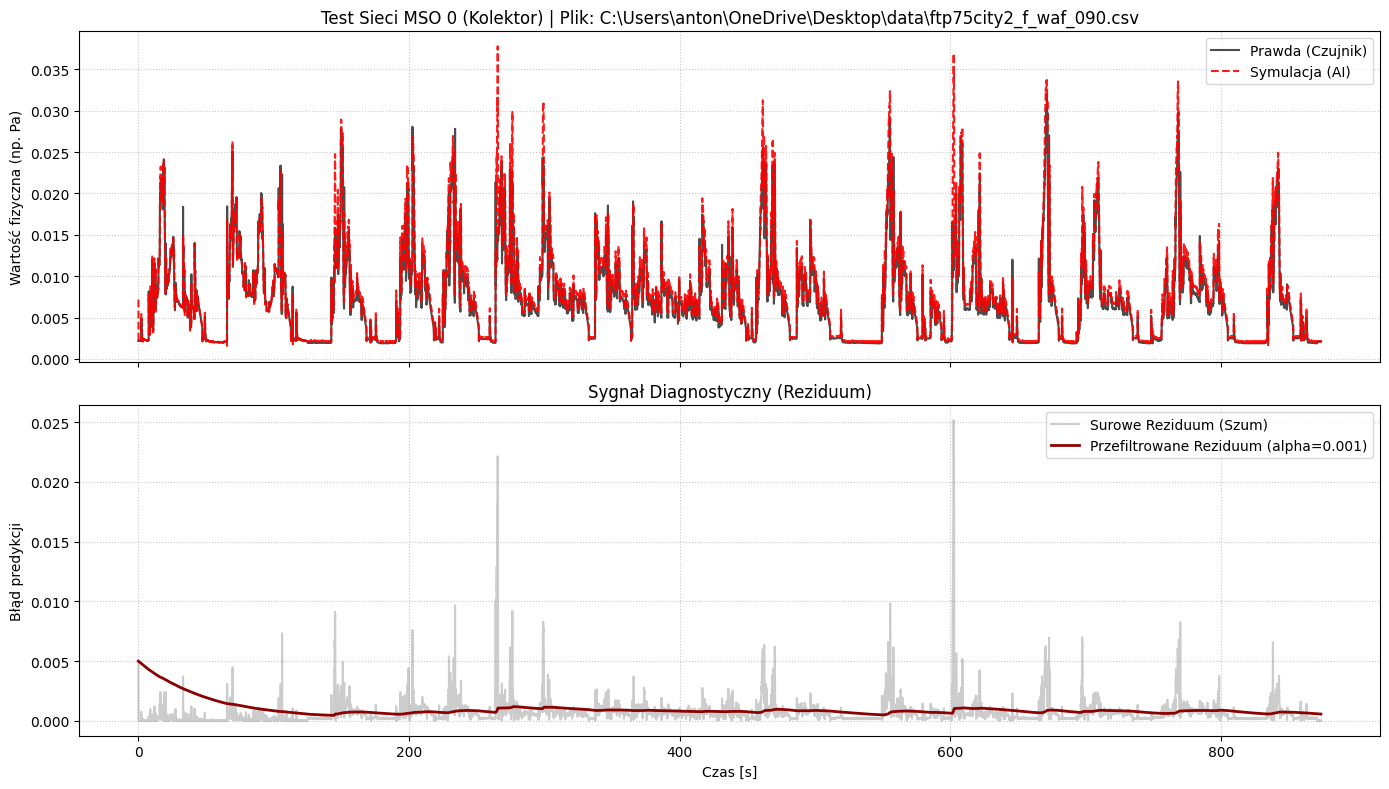

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0007
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0050


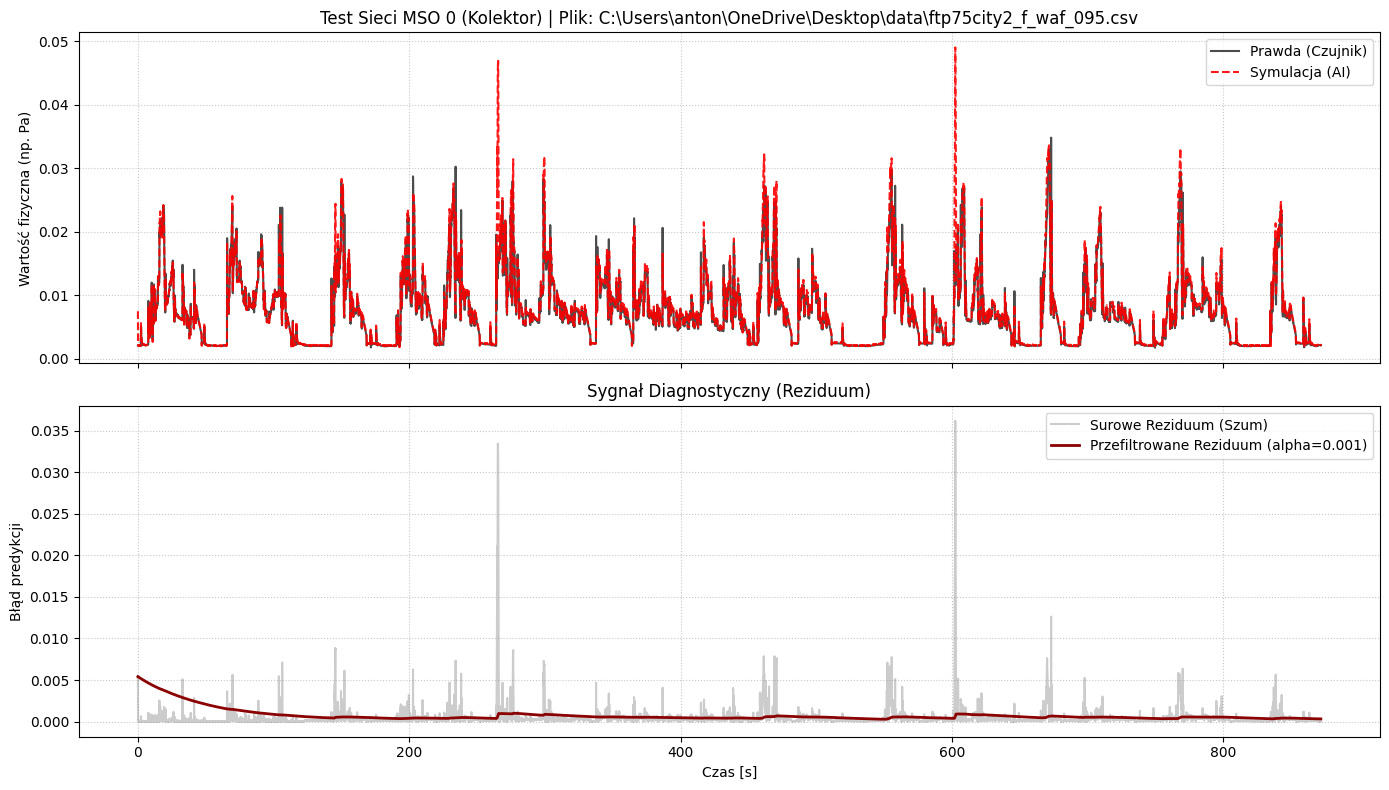

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0005
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0054


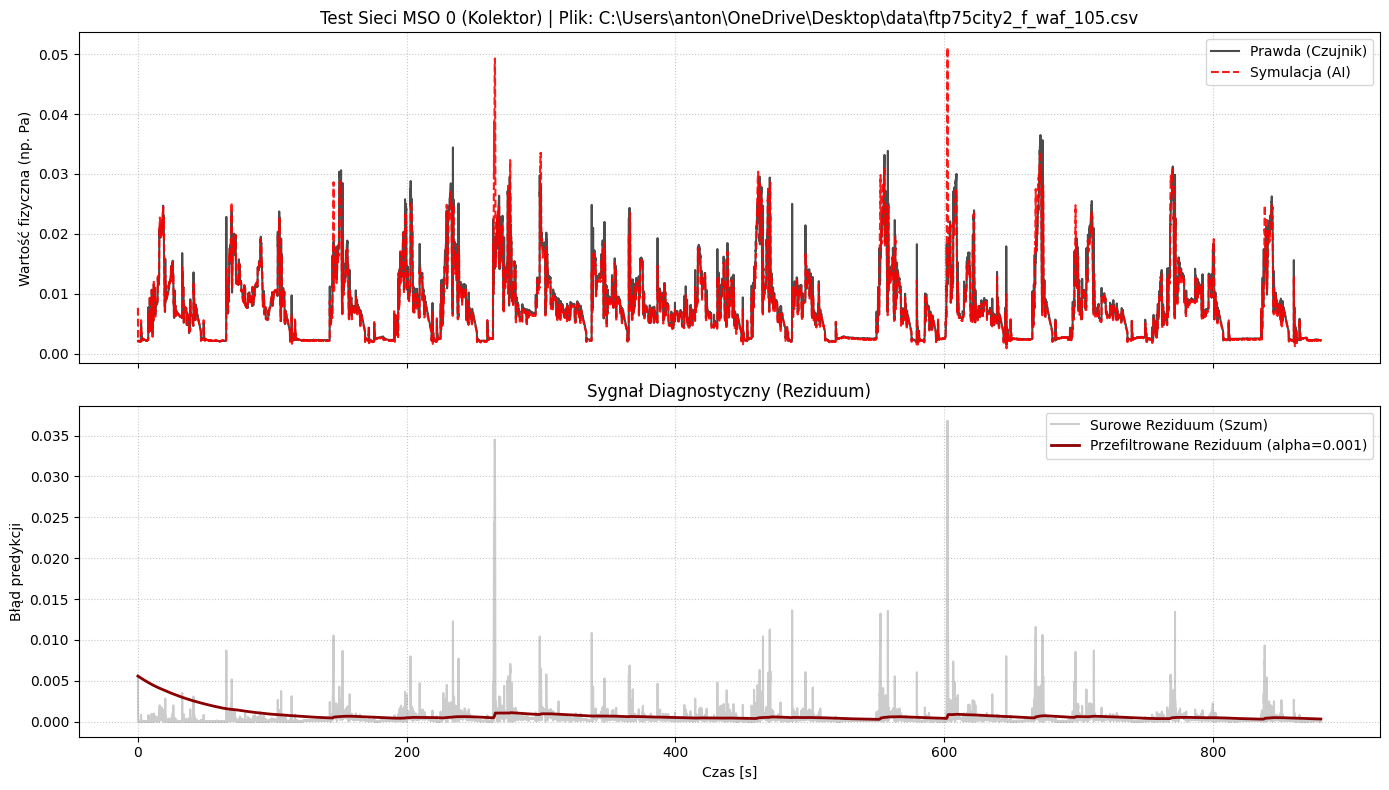

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0005
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0056


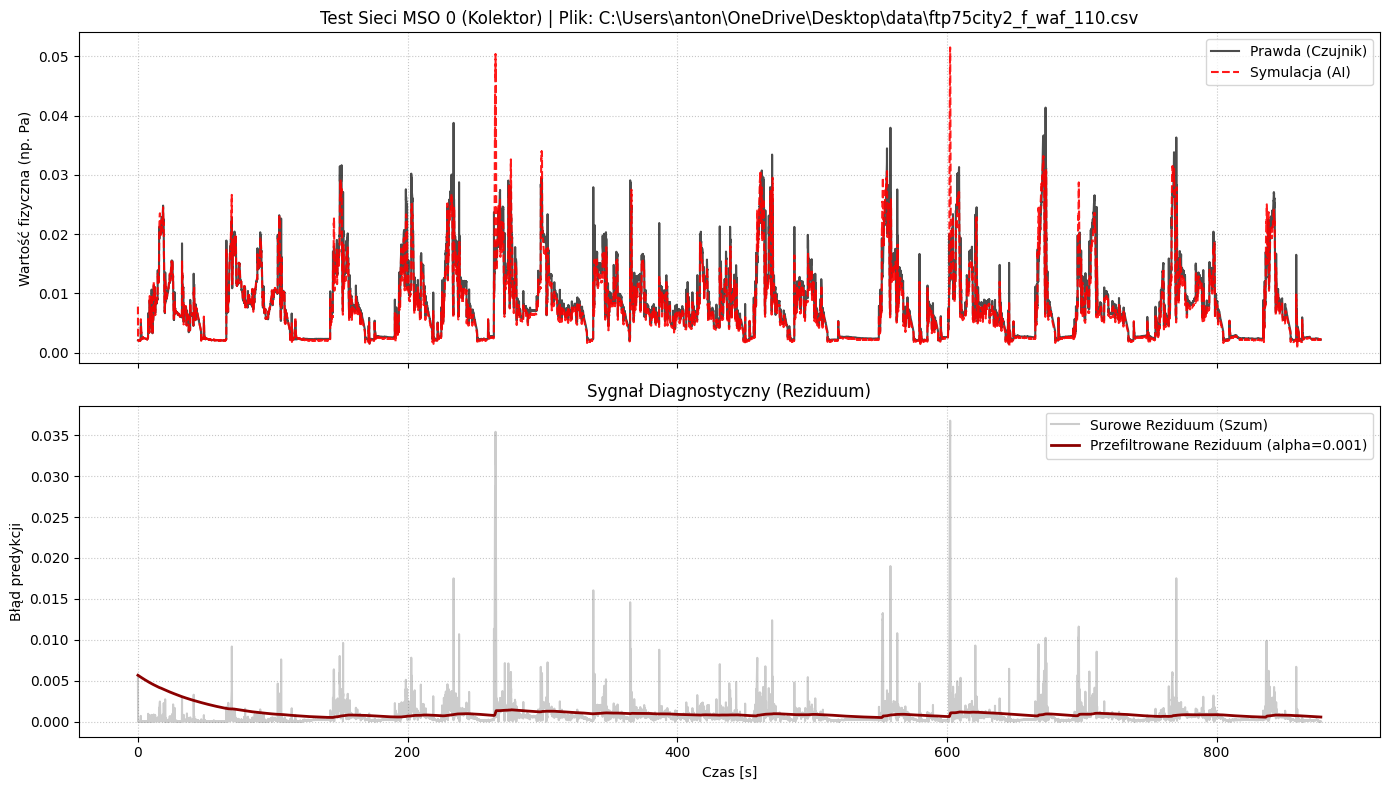

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0008
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0057


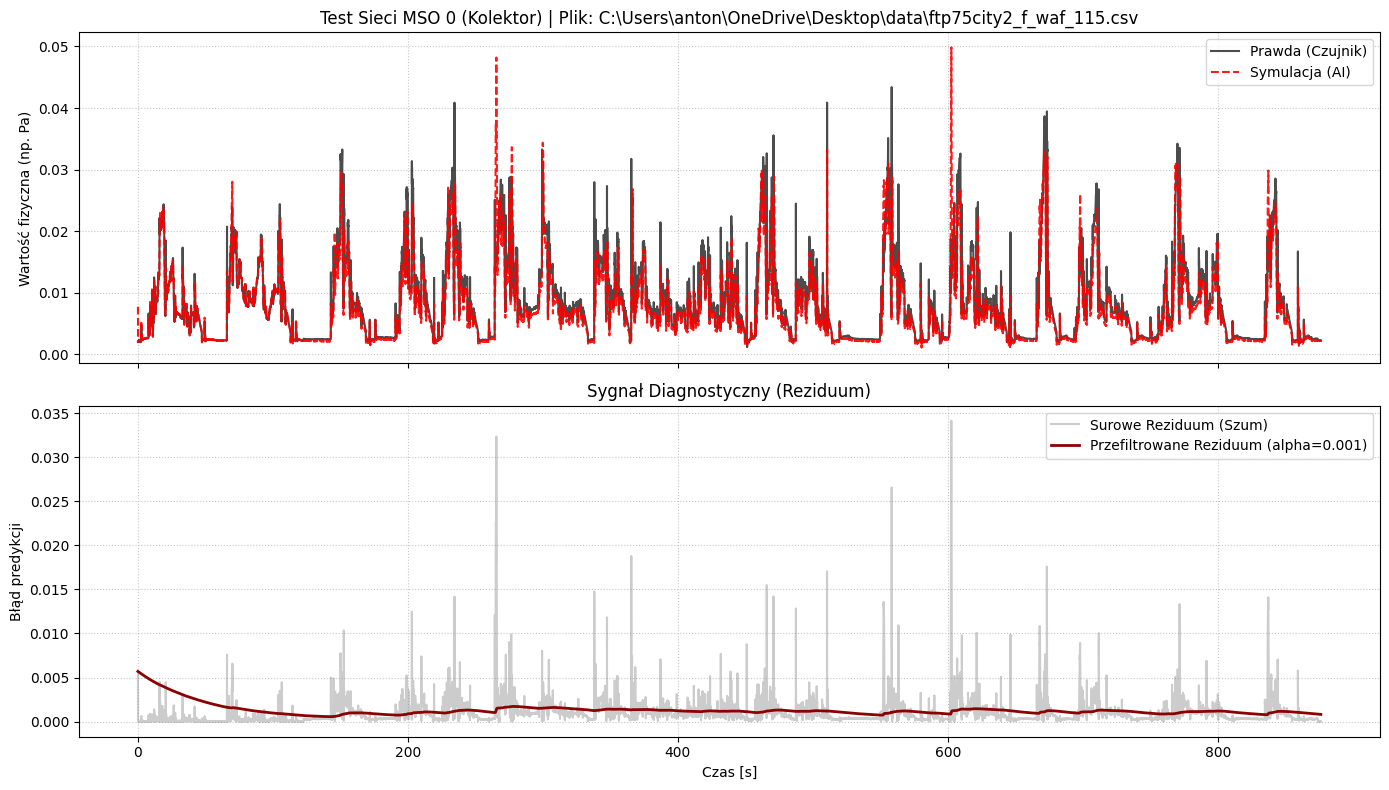

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0010
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0057


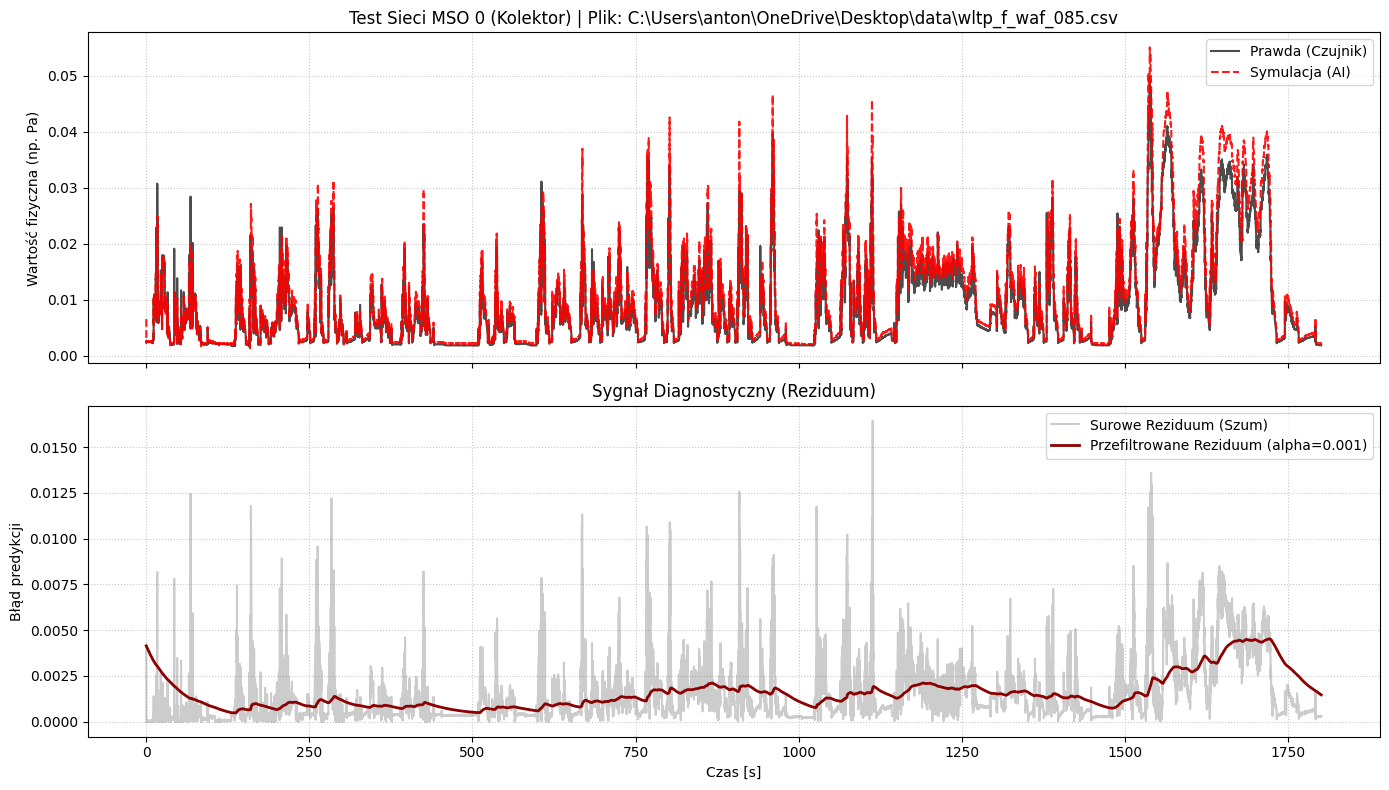

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0015
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0045


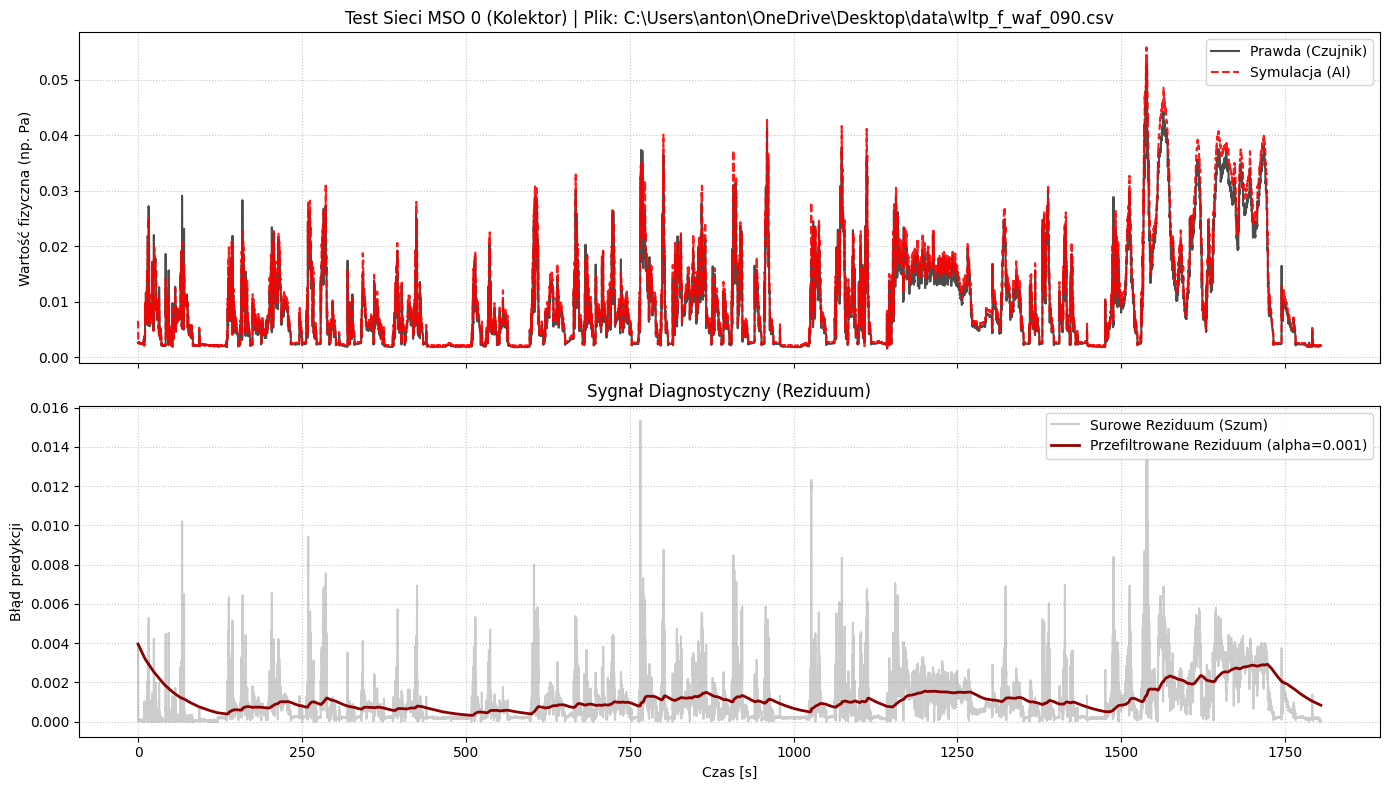

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0011
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0040


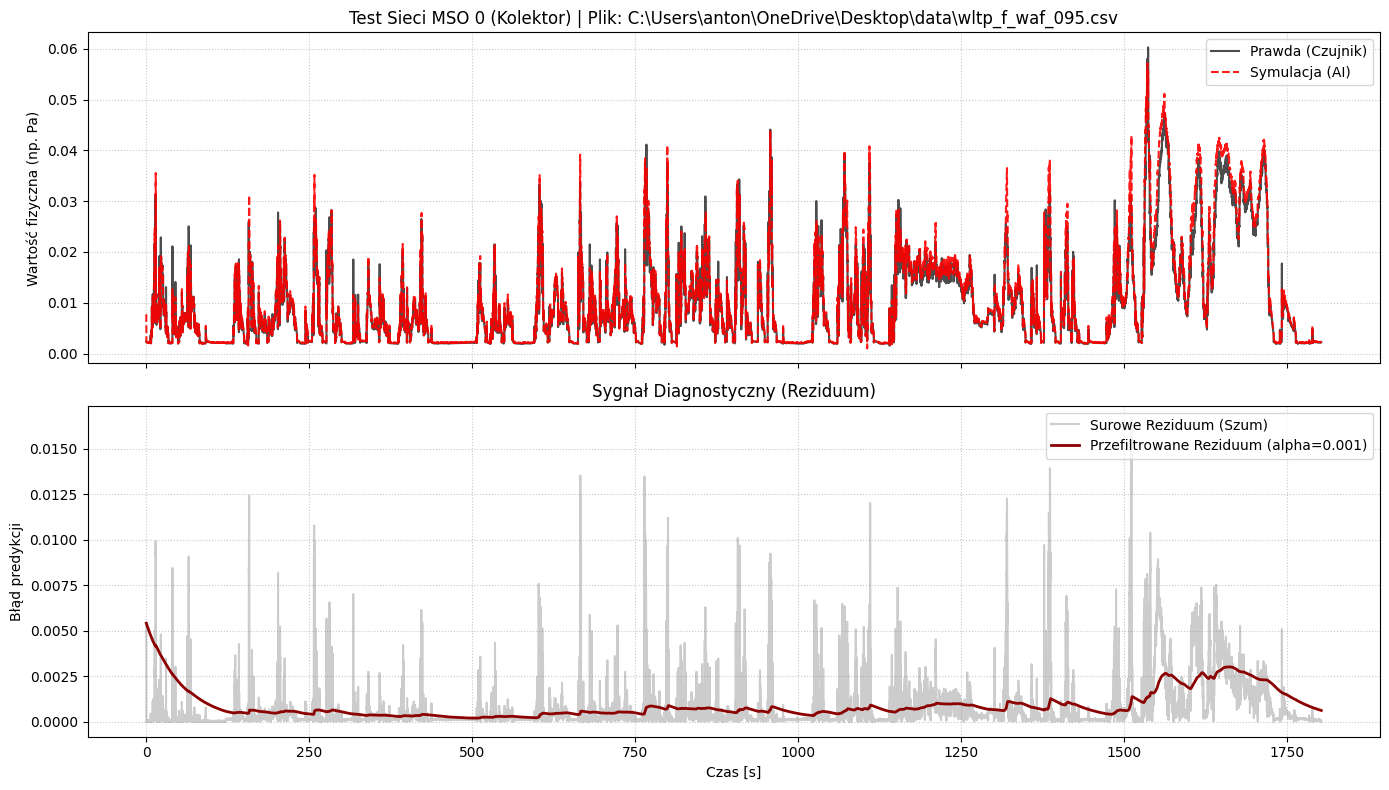

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0008
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0054


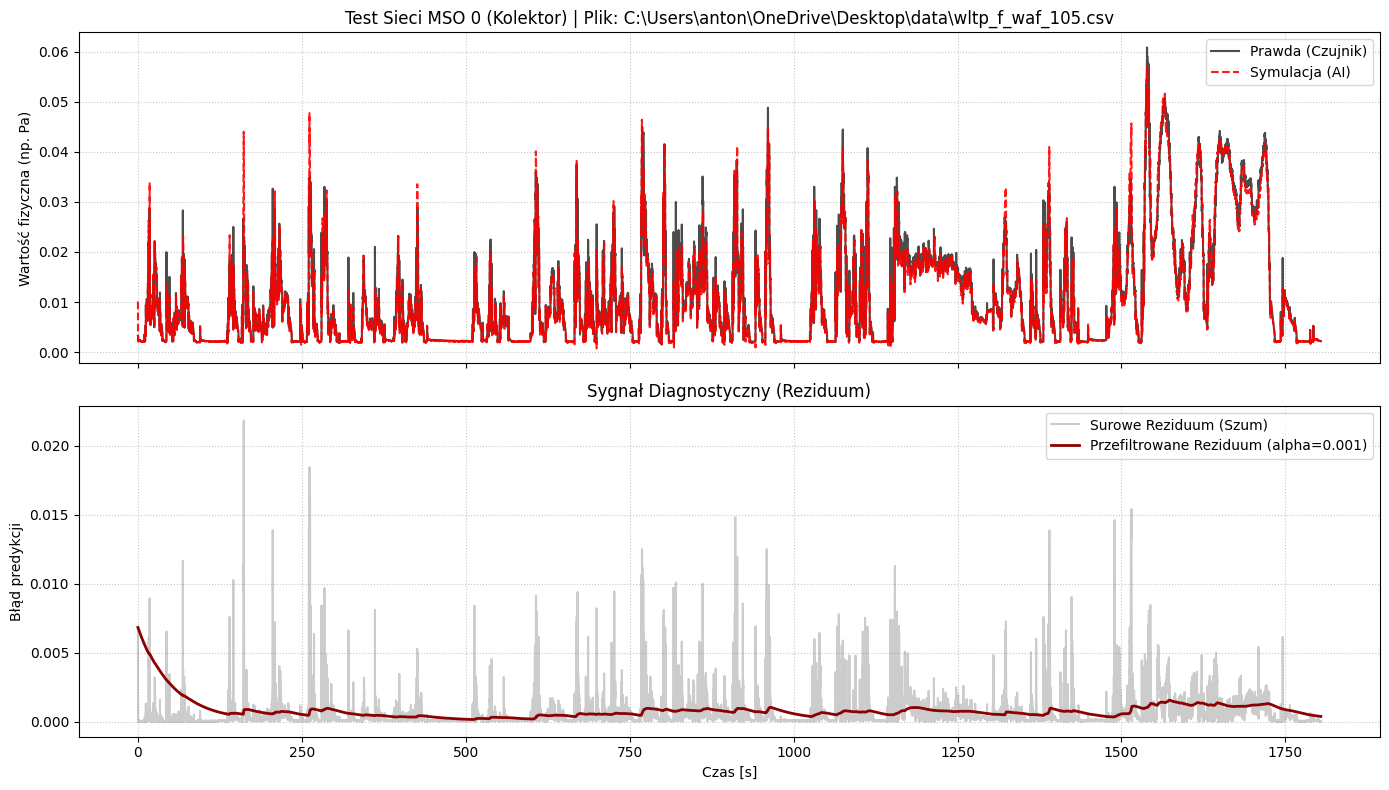

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0006
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0068


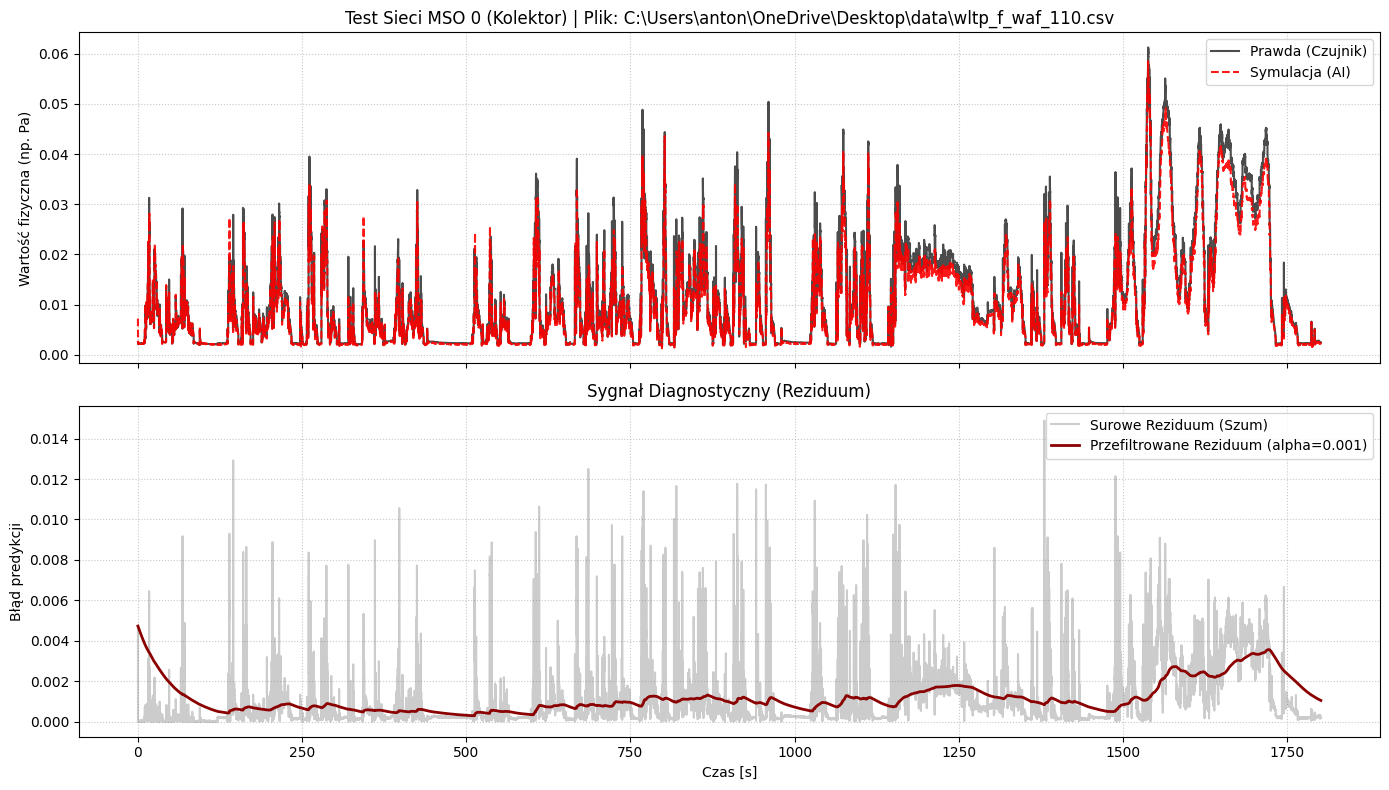

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0011
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0047


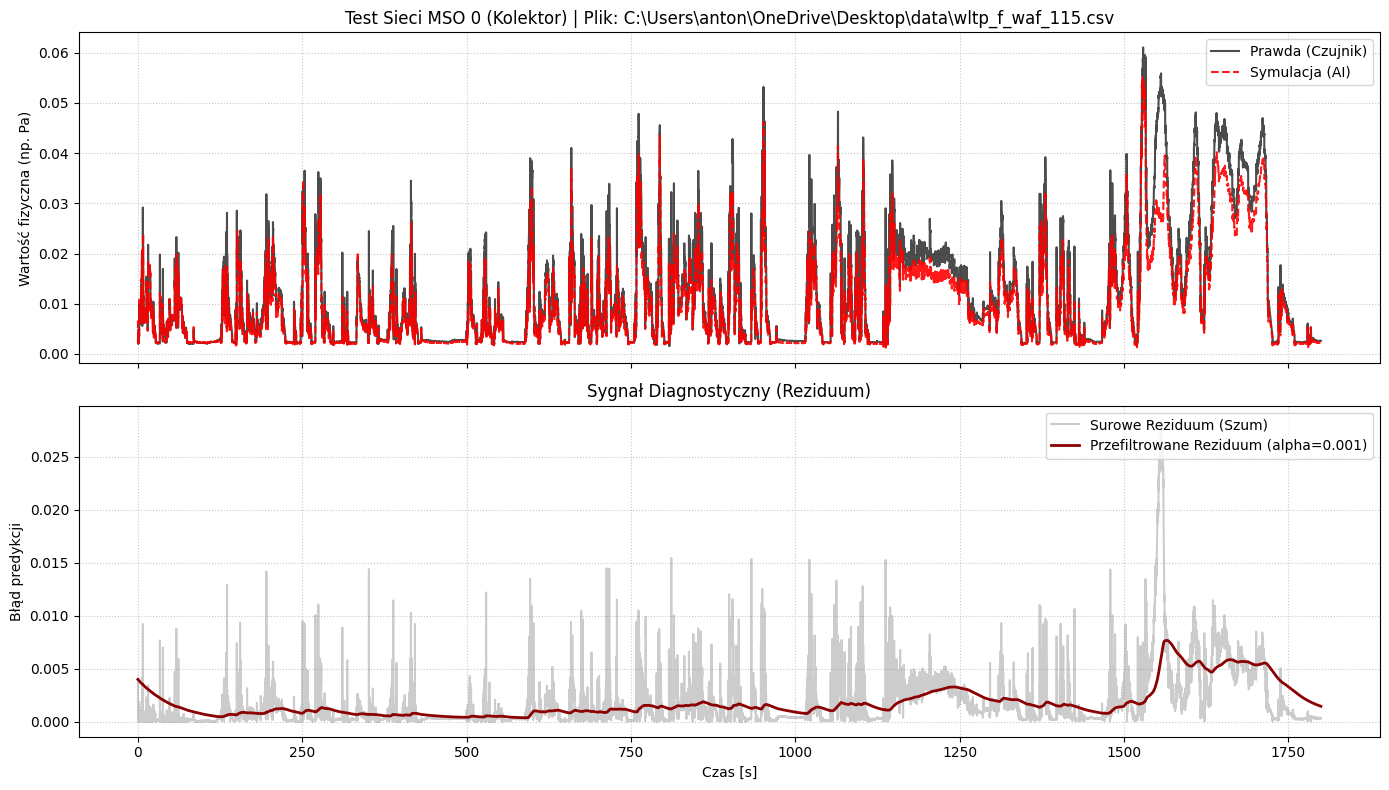

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0017
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0077


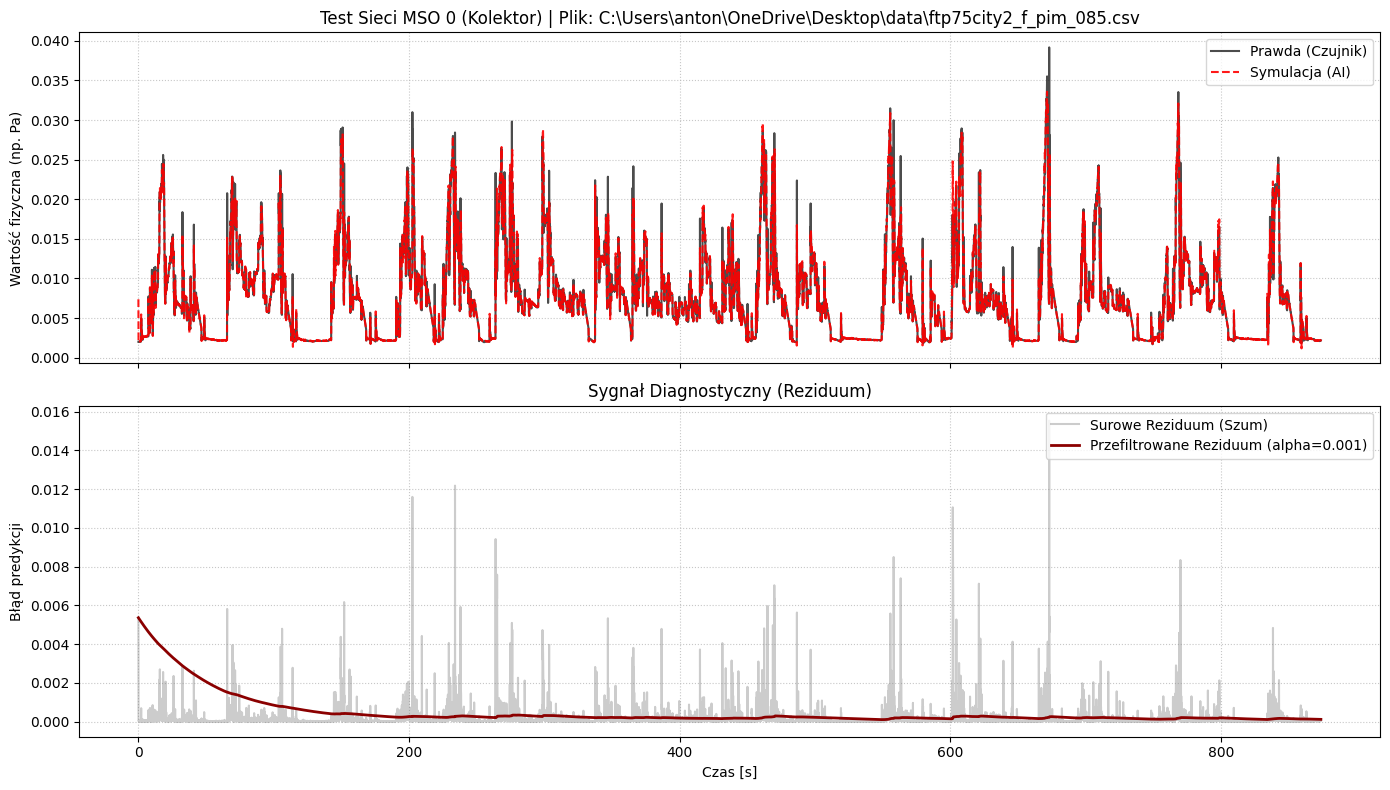

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0002
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0054


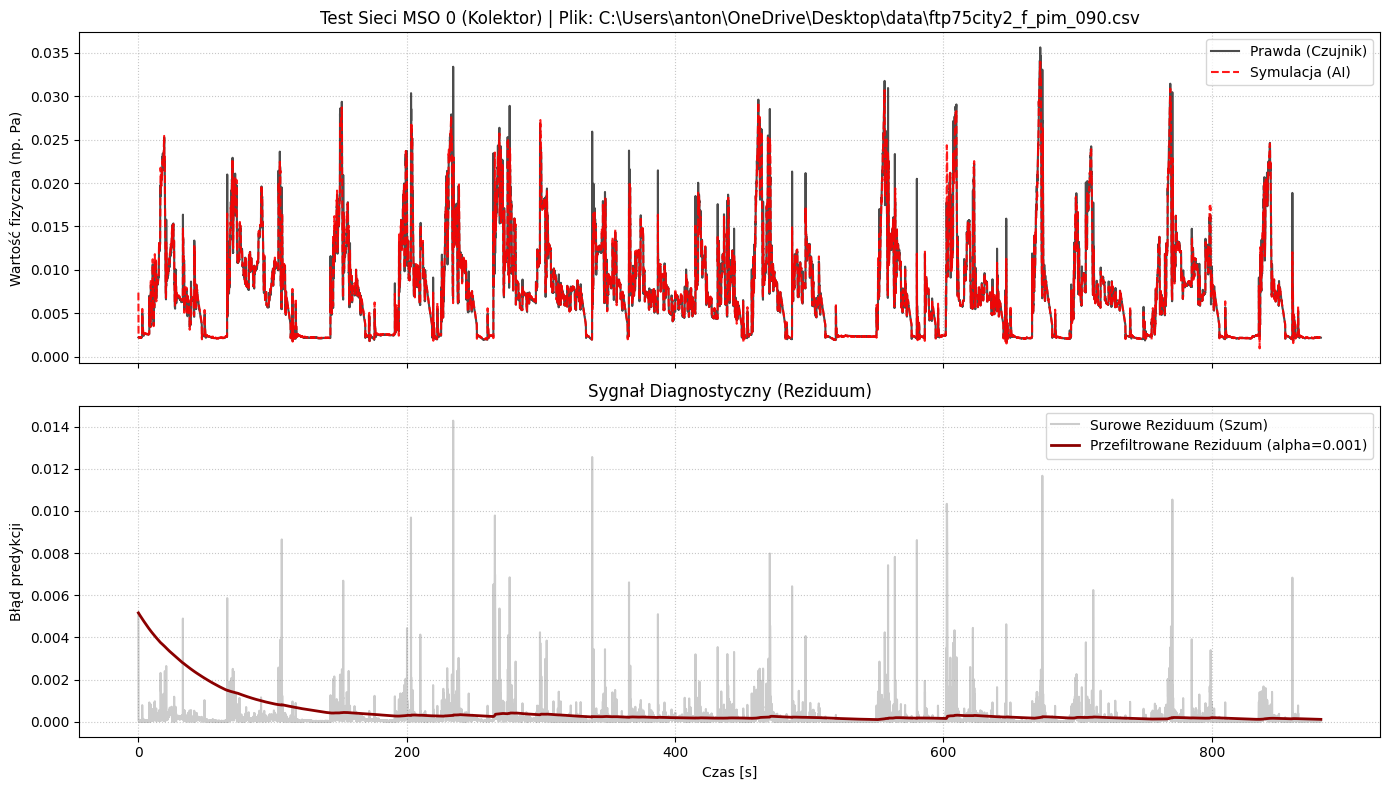

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0002
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0052


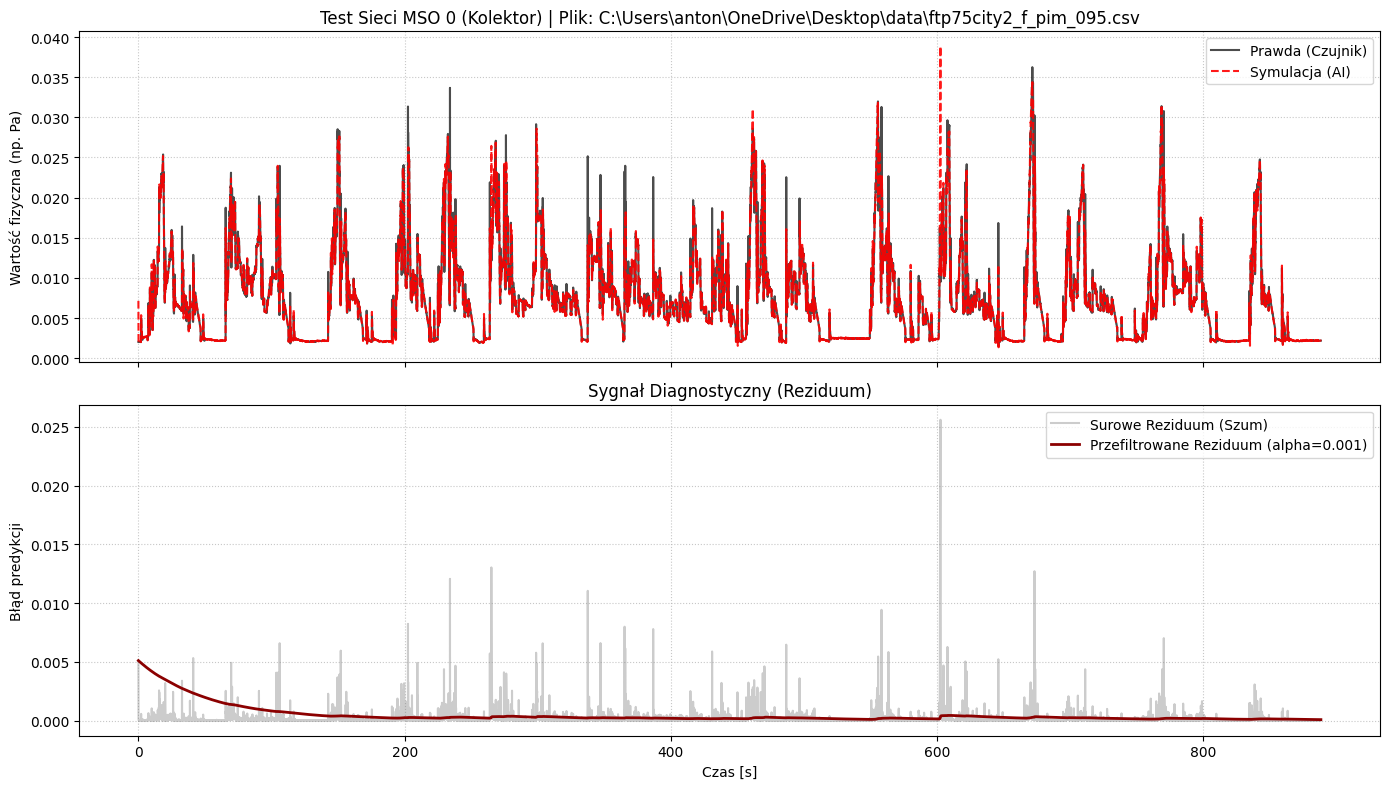

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0002
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0051


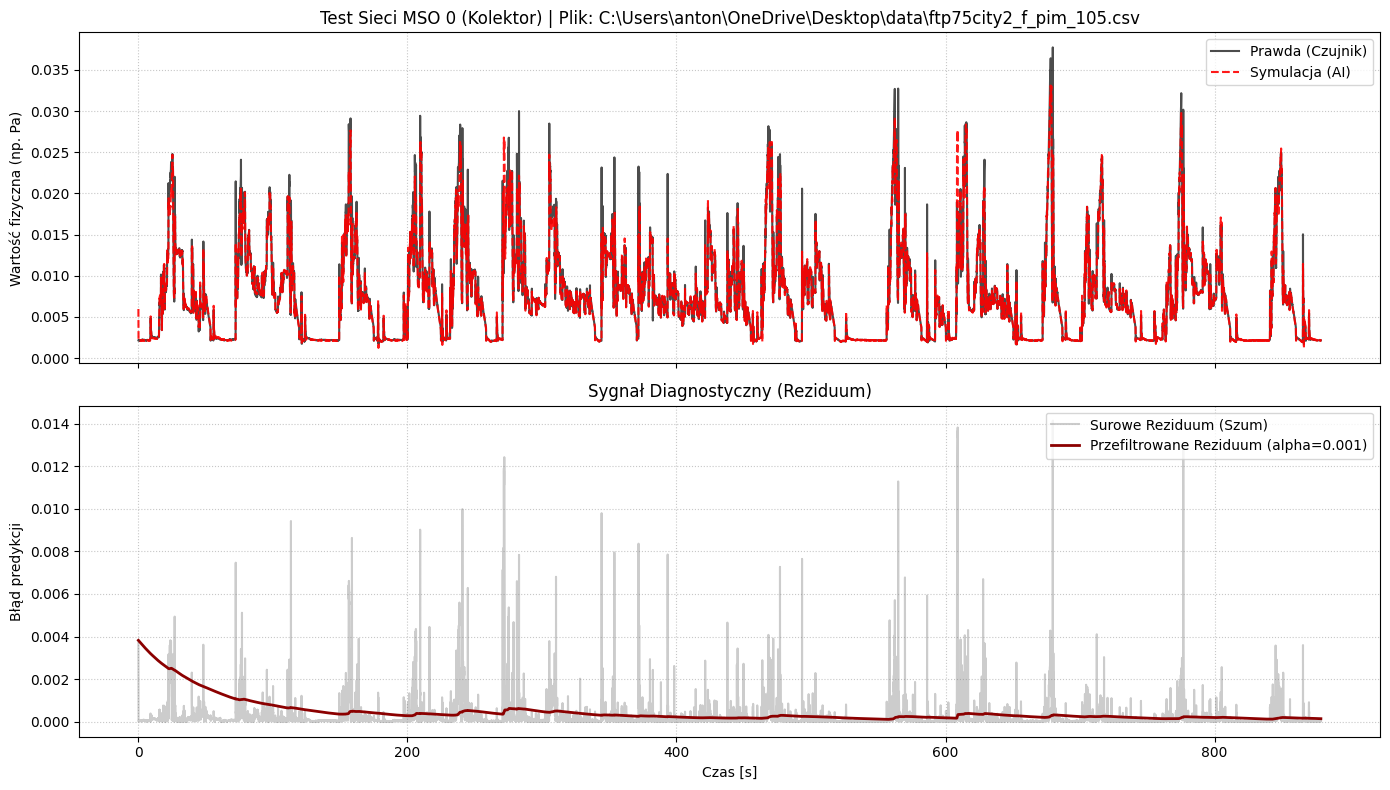

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0003
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0038


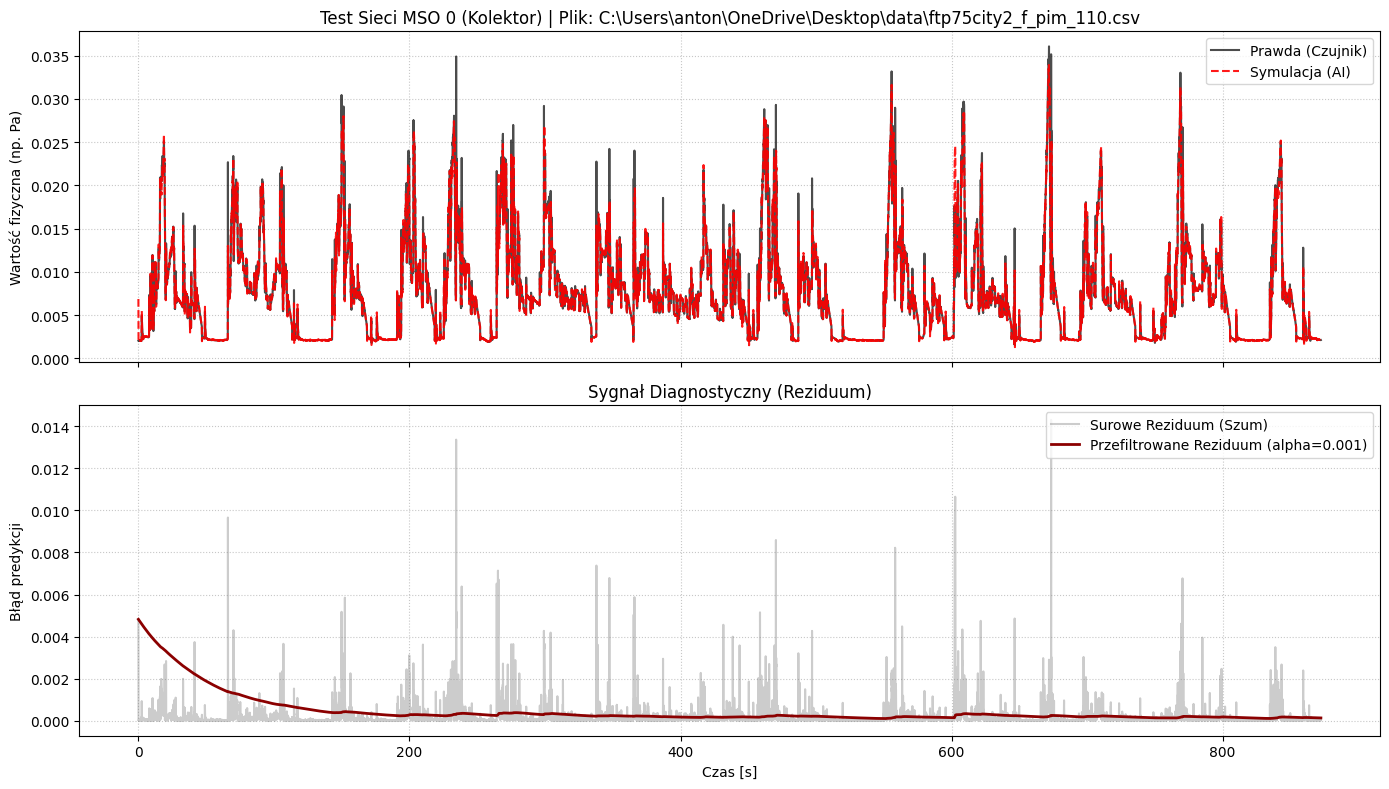

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0002
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0048


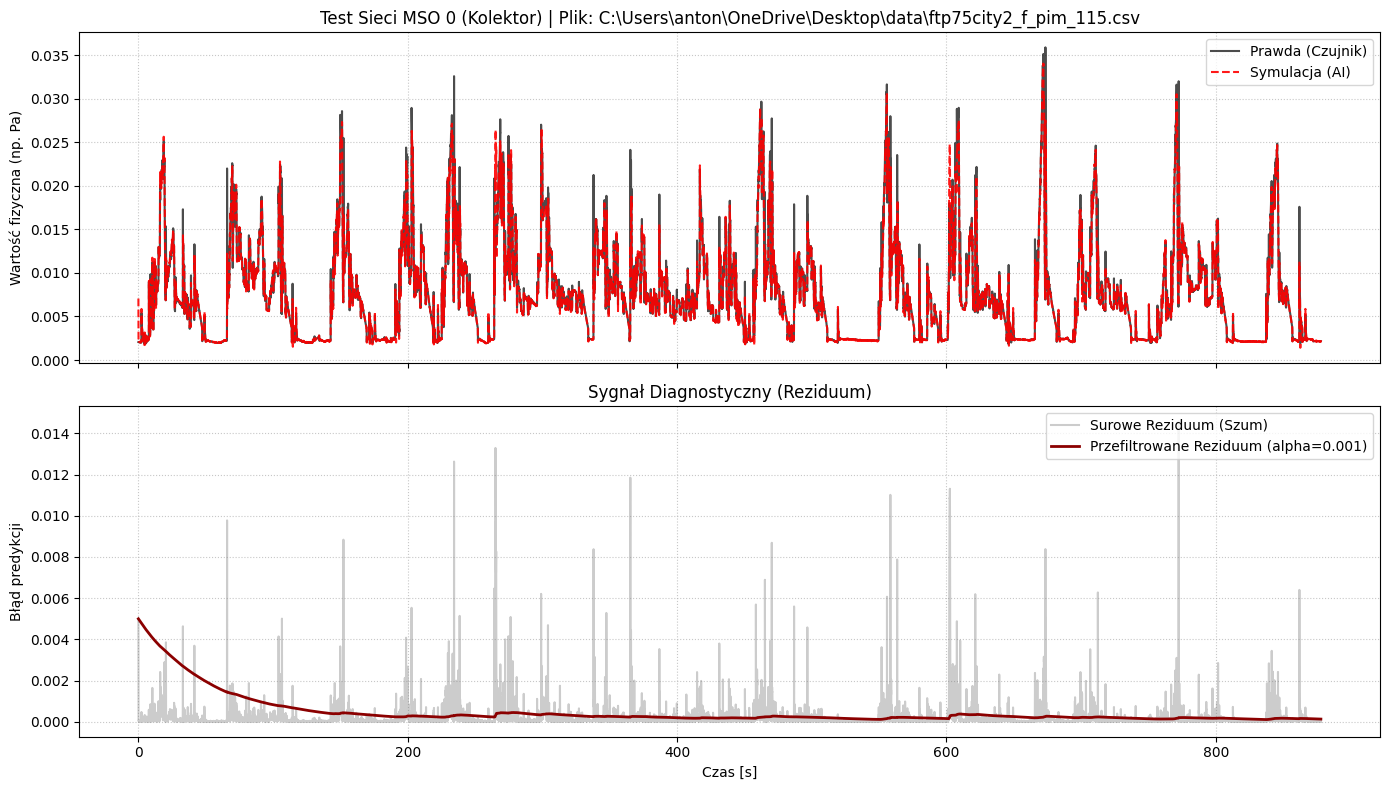

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0002
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0050


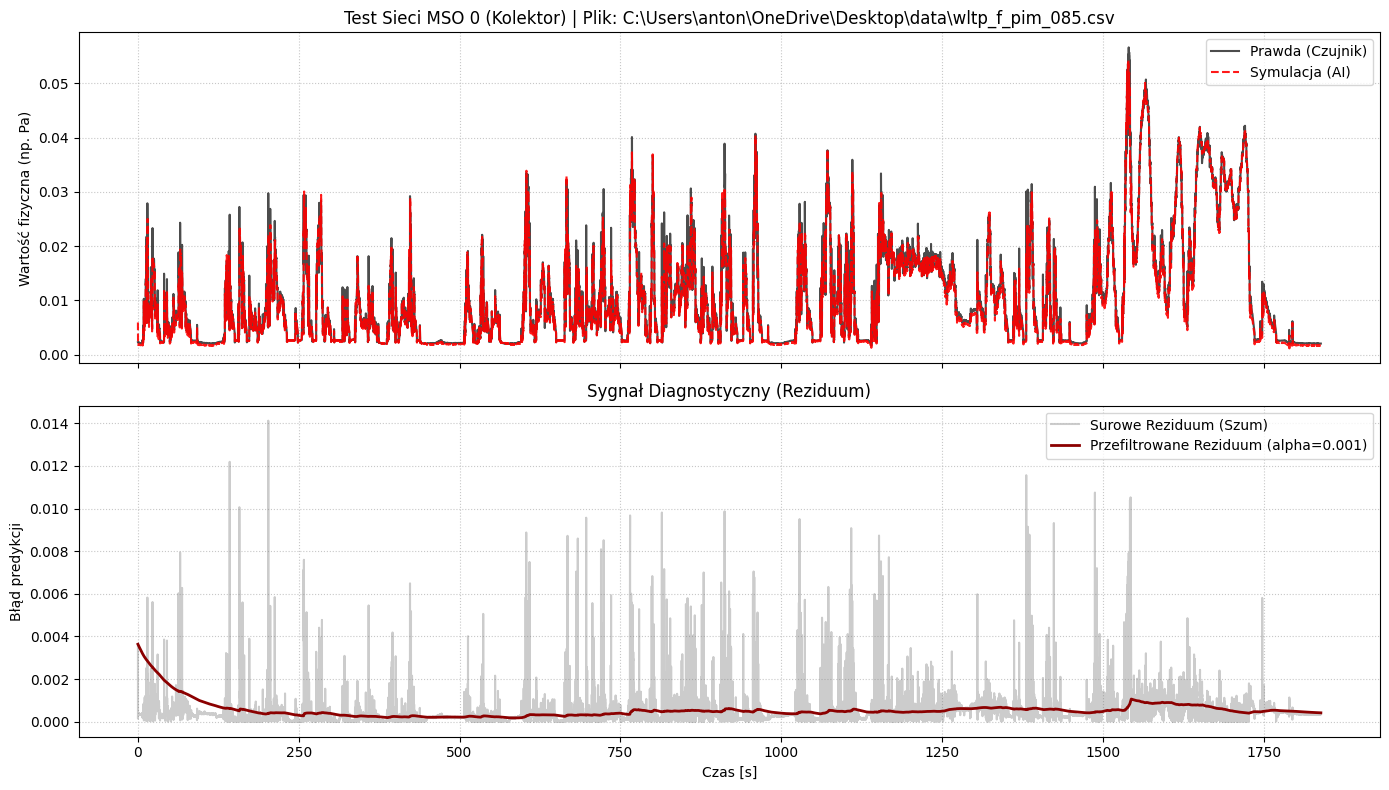

Średni błąd bezwzględny (MAE po rozgrzewce): 0.0005
Maksymalny błąd przefiltrowany (po rozgrzewce): 0.0036


KeyboardInterrupt: 

In [6]:
model0 = GreyBoxSystem_MSO0(T_sample=0.05)

# 3. Wczytanie MÓZGU (wytrenowanych wag) i SKALERÓW z dysku
model0.load_state_dict(torch.load('szara_skrzynka_waf.pth'))
model0.eval() # Ustawienie modelu w tryb predykcji
scaler_u0 = joblib.load('scaler_u_waf.pkl')
scaler_y0 = joblib.load('scaler_y_waf.pkl')

print("Model MSO 0 i skalery zostały pomyślnie wczytane z dysku!")

pliki_testowe = [FAULTY_FILES_WAF, FAULTY_FILES_PIM]


for lista in pliki_testowe:
   for plik in lista:
       validate_and_plot(model0, scaler_u0, scaler_y0, u_cols_0, y_cols_0, plik, "Test Sieci MSO 0 (Kolektor)", alpha=0.001, threshold=None)

Tutaj nie powinno być detekcji

In [6]:
#for file in FAULTY_FILES_WAF:
    #validate_and_plot(model0, scaler_u0, scaler_y0, u_cols_0, y_cols_0, file, "Test Sieci MSO 0 (Kolektor)", alpha=0.001, threshold=2100.0)

Fine tuning

In [11]:
pliki_do_walidacji = FAULTY_FILES_PIM + FAULTY_FILES_PIC + FAULTY_FILES_IML + FAULTY_FILES_WAF + HEALTHY_FILES

czestotliwosc_Hz = 20
czas_zdrowy_s = 110
limit_probek = czas_zdrowy_s * czestotliwosc_Hz
burn_in = 100 

alpha = 0.001 

wszystkie_rezidua_przefiltrowane = []
wszystkie_rezidua_surowe_bias = []

print("Rozpoczynam analizę statystyczną na przefiltrowanych zdrowych fragmentach...")
model0.eval()

with torch.no_grad():
    for plik in pliki_do_walidacji:
        df = pd.read_csv(plik)
        df_zdrowe = df.iloc[:limit_probek]
        
        X_tensor = torch.tensor(scaler_u0.transform(df_zdrowe[u_cols_0].values), dtype=torch.float32).unsqueeze(0)
        Y_tensor = torch.tensor(scaler_y0.transform(df_zdrowe[y_cols_0].values), dtype=torch.float32).unsqueeze(0)
        
        x_init = torch.zeros(1, model0.num_states)
        y_pred = model0(X_tensor, x_init)
        
        y_pred_real = scaler_y0.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
        y_true_real = scaler_y0.inverse_transform(Y_tensor[0].cpu().numpy().reshape(-1, 1))
        
        # 1. Surowy błąd bezwzględny
        e_raw_abs = np.abs(y_true_real - y_pred_real).flatten()
        
        # 2. Surowy błąd ze znakiem (do sprawdzania Biasu)
        e_raw_znak = (y_true_real - y_pred_real).flatten()
        
        # 3. FILTRACJA EMA (To, czego brakowało!)
        e_filtered = np.zeros_like(e_raw_abs)
        e_filtered[0] = e_raw_abs[0]
        for i in range(1, len(e_raw_abs)):
            e_filtered[i] = alpha * e_raw_abs[i] + (1 - alpha) * e_filtered[i-1]
        
        # Zapisujemy do głównej listy (omijając strefę Burn-in)
        wszystkie_rezidua_przefiltrowane.extend(e_filtered[burn_in:])
        wszystkie_rezidua_surowe_bias.extend(e_raw_znak[burn_in:])

# Konwersja na szybkie tablice NumPy
wszystkie_rezidua_przefiltrowane = np.array(wszystkie_rezidua_przefiltrowane)
wszystkie_rezidua_surowe_bias = np.array(wszystkie_rezidua_surowe_bias)

# OBLICZANIE STATYSTYK NA SYGNALE PRZEFILTROWANYM
srednia_filt = np.mean(wszystkie_rezidua_przefiltrowane)
std_filt = np.std(wszystkie_rezidua_przefiltrowane)
bias_modelu = np.mean(wszystkie_rezidua_surowe_bias)

print(f"\n{'='*50}")
print(f"WYNIKI WALIDACJI STATYSTYCZNEJ (MSO 0) - Z FILTREM (alpha={alpha})")
print(f"{'='*50}")
print(f"Średni uchyb (wygładzony)     : {srednia_filt:.2f} Pa")
print(f"Odchylenie standardowe (sigma): {std_filt:.2f} Pa")
print(f"Błąd systematyczny (Bias)     : {bias_modelu:.2f} Pa")
print(f"-"*50)

# Reguła 3 sigm (99.7% pewności) do wyznaczania progów:
prog_3sigma = srednia_filt + (3 * std_filt)
prog_6sigma = srednia_filt + (6 * std_filt)

print(f"💡 WNIOSKI DLA PROGÓW (Thresholds) DLA SYGNAŁU PRZEFILTROWANEGO:")
print(f"-> Bezpieczny próg (3 sigma) to {prog_3sigma:.2f} Pa.")
print(f"-> Bardzo ostrożny próg (6 sigma) to {prog_6sigma:.2f} Pa.")

Rozpoczynam analizę statystyczną na przefiltrowanych zdrowych fragmentach...

WYNIKI WALIDACJI STATYSTYCZNEJ (MSO 0) - Z FILTREM (alpha=0.001)
Średni uchyb (wygładzony)     : 1520.13 Pa
Odchylenie standardowe (sigma): 1263.17 Pa
Błąd systematyczny (Bias)     : -115.81 Pa
--------------------------------------------------
💡 WNIOSKI DLA PROGÓW (Thresholds) DLA SYGNAŁU PRZEFILTROWANEGO:
-> Bezpieczny próg (3 sigma) to 5309.64 Pa.
-> Bardzo ostrożny próg (6 sigma) to 9099.15 Pa.


In [12]:
pliki_do_walidacji = FAULTY_FILES_WAF + HEALTHY_FILES

czestotliwosc_Hz = 20
czas_zdrowy_s = 110
limit_probek = czas_zdrowy_s * czestotliwosc_Hz
burn_in = 100 

alpha = 0.001 

wszystkie_rezidua_przefiltrowane = []
wszystkie_rezidua_surowe_bias = []

print("Rozpoczynam analizę statystyczną na przefiltrowanych zdrowych fragmentach...")
model0.eval()

with torch.no_grad():
    for plik in pliki_do_walidacji:
        df = pd.read_csv(plik)
        
        X_tensor = torch.tensor(scaler_u0.transform(df_zdrowe[u_cols_0].values), dtype=torch.float32).unsqueeze(0)
        Y_tensor = torch.tensor(scaler_y0.transform(df_zdrowe[y_cols_0].values), dtype=torch.float32).unsqueeze(0)
        
        x_init = torch.zeros(1, model0.num_states)
        y_pred = model0(X_tensor, x_init)
        
        y_pred_real = scaler_y0.inverse_transform(y_pred[0].cpu().numpy().reshape(-1, 1))
        y_true_real = scaler_y0.inverse_transform(Y_tensor[0].cpu().numpy().reshape(-1, 1))
        
        # 1. Surowy błąd bezwzględny
        e_raw_abs = np.abs(y_true_real - y_pred_real).flatten()
        
        # 2. Surowy błąd ze znakiem (do sprawdzania Biasu)
        e_raw_znak = (y_true_real - y_pred_real).flatten()
        
        # 3. FILTRACJA EMA (To, czego brakowało!)
        e_filtered = np.zeros_like(e_raw_abs)
        e_filtered[0] = e_raw_abs[0]
        for i in range(1, len(e_raw_abs)):
            e_filtered[i] = alpha * e_raw_abs[i] + (1 - alpha) * e_filtered[i-1]
        
        # Zapisujemy do głównej listy (omijając strefę Burn-in)
        wszystkie_rezidua_przefiltrowane.extend(e_filtered[burn_in:])
        wszystkie_rezidua_surowe_bias.extend(e_raw_znak[burn_in:])

# Konwersja na szybkie tablice NumPy
wszystkie_rezidua_przefiltrowane = np.array(wszystkie_rezidua_przefiltrowane)
wszystkie_rezidua_surowe_bias = np.array(wszystkie_rezidua_surowe_bias)

# OBLICZANIE STATYSTYK NA SYGNALE PRZEFILTROWANYM
srednia_filt = np.mean(wszystkie_rezidua_przefiltrowane)
std_filt = np.std(wszystkie_rezidua_przefiltrowane)
bias_modelu = np.mean(wszystkie_rezidua_surowe_bias)

print(f"\n{'='*50}")
print(f"WYNIKI WALIDACJI STATYSTYCZNEJ (MSO 0) - Z FILTREM (alpha={alpha})")
print(f"{'='*50}")
print(f"Średni uchyb (wygładzony)     : {srednia_filt:.2f} Pa")
print(f"Odchylenie standardowe (sigma): {std_filt:.2f} Pa")
print(f"Błąd systematyczny (Bias)     : {bias_modelu:.2f} Pa")
print(f"-"*50)

# Reguła 3 sigm (99.7% pewności) do wyznaczania progów:
prog_3sigma = srednia_filt + (3 * std_filt)
prog_6sigma = srednia_filt + (6 * std_filt)

print(f"💡 WNIOSKI DLA PROGÓW (Thresholds) DLA SYGNAŁU PRZEFILTROWANEGO:")
print(f"-> Bezpieczny próg (3 sigma) to {prog_3sigma:.2f} Pa.")
print(f"-> Bardzo ostrożny próg (6 sigma) to {prog_6sigma:.2f} Pa.")

Rozpoczynam analizę statystyczną na przefiltrowanych zdrowych fragmentach...

WYNIKI WALIDACJI STATYSTYCZNEJ (MSO 0) - Z FILTREM (alpha=0.001)
Średni uchyb (wygładzony)     : 839.15 Pa
Odchylenie standardowe (sigma): 255.29 Pa
Błąd systematyczny (Bias)     : 95.84 Pa
--------------------------------------------------
💡 WNIOSKI DLA PROGÓW (Thresholds) DLA SYGNAŁU PRZEFILTROWANEGO:
-> Bezpieczny próg (3 sigma) to 1605.01 Pa.
-> Bardzo ostrożny próg (6 sigma) to 2370.86 Pa.
